# CA2 Pipeline V2 — HOG + Random Forest vs Improved CNN

**Module:** ANL403 Applied Machine Learning
**Assessment:** CA2 — Image classification on ImageNet-1k subsets
**Methodology:** Traditional ML baseline (HOG + RF) versus DL approach (enhanced CNN with BatchNorm)

In this notebook, a machine learning pipeline for image classification with true long-tail class imbalance (≈40:1 ratio) is implemented, contrasting a traditional ML baseline using the combination of HOG + RF to a deeper CNN model. CRISP-DM methodology is followed for implementing the pipeline from business understanding to modeling & evaluation phases.

**Research question:** *How effective are traditional and deep learning algorithms at image classification when there is a realistic class imbalance problem?*

**Key performance metrics:** weighted F1 score (primary), macro F1, per-class precision, recall, F1, accuracy, and confusion matrix.

## 1. Environment Setup

Imports, reproducibility seeds, and device detection.

In [ ]:
import io                           # In-memory byte streams
import json                         # Parsing and writing JSON data
import time                         # Measuring elapsed time or adding delays
import warnings                     # Contro how Python warning messages are displayed
from pathlib import Path            # Handling file and directory paths in an OS-agnostic way

import numpy as np                  # Numerical array operations
import pandas as pd                 # Data manipulation
from PIL import Image               # Loading and processing image files
import matplotlib.pyplot as plt     # Plot interface
import seaborn as sns               # Statistical data visualisation

from skimage.feature import hog     # Histogram of Oriented Gradients
from skimage.color import rgb2gray  # Convert RGB images to grayscale

from joblib import Parallel, delayed    # Running functions in parallel across multiple CPU cores

from sklearn.ensemble import RandomForestClassifier     # Classification model
from sklearn.model_selection import train_test_split    # Funcion to split data
from sklearn.preprocessing import LabelEncoder          # Convert categorical labels into numeric values
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)  # Evaluation metrics
from sklearn.utils.class_weight import compute_class_weight # Calculate weights for imbalance class distributions

import torch                                        # Pytorch library for deep learning
import torch.nn as nn                               # Neural network module
import torch.optim as optim                         # Optimiser module
from torch.utils.data import Dataset, DataLoader    # Creating custom datasets and batching data
import torchvision.transforms as transforms         # Image transformation utilities

from huggingface_hub import hf_hub_download         # To download files directly from the Hugging Face Hub

warnings.filterwarnings('ignore')       # Suppress all warning messages for being printed

SEED = 42               # Value for reproducibility
np.random.seed(SEED)    
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')   # Sets compute device to GPU if available, otherwise falls back to CPU
print(f'PyTorch device: {DEVICE}')
print(f'Torch: {torch.__version__} | NumPy: {np.__version__}')

PyTorch device: cpu
Torch: 2.12.0+cpu | NumPy: 2.4.4


c:\Users\ivan_\Desktop\Data Analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

All configurable parameters can be found here. The paths are relative to the notebook’s directory since we want our project to be portable.

The 15 classes were chosen using the ImageNet IDs 74–99 in order to get all ranges of frequency in the dataset, thus obtaining the long-tail effect with 5 common, 5 median, 4 rare, and 1 super-rare classes.

In [2]:
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR

IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 25
LR = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 6

SOURCE_PARQUET = DATA_DIR / 'merged_dataset.parquet'
SUBSET_PARQUET = DATA_DIR / 'longtail_sample_v2.parquet'
LABEL_MAP_PATH = DATA_DIR / 'imagenet-1k-id2label.json'
WEIGHTS_PATH = DATA_DIR / 'cnn_v2_weights.pth'

# 15 classes spanning the source count distribution (~50 to ~3600)
SELECTED_CLASSES = [75, 84, 89, 93, 94,   # abundant tier (~3600 each)
                    76, 78, 80, 82, 97,   # medium tier   (~2600 each)
                    74, 81, 98, 79,       # low tier      (~1900-2600)
                    99]                   # tail          (~50)

# Target sample counts per class — explicit long-tail (sum ≈ 14,600)
TARGET_PER_CLASS = {
    75: 2000, 84: 1900, 89: 1800, 93: 1700, 94: 1600,   # 5 abundant
    76: 1000, 78: 900,  80: 800,  82: 700,  97: 600,    # 5 medium
    74: 500,  81: 400,  98: 350,  79: 300,              # 4 low
    99: 50,                                              # 1 tail
}

N_CLASSES = len(SELECTED_CLASSES)
assert N_CLASSES == 15

print(f'Working directory: {NOTEBOOK_DIR}')
print(f'Classes: {N_CLASSES} | Target total samples: {sum(TARGET_PER_CLASS.values()):,}')
print(f'Imbalance ratio (target): {max(TARGET_PER_CLASS.values())/min(TARGET_PER_CLASS.values()):.0f}:1')

Working directory: c:\Users\ivan_\Desktop\Data Analytics\Applied ML\AML_CA2
Classes: 15 | Target total samples: 14,600
Imbalance ratio (target): 40:1


## 3. ImageNet label map

Downloads the `id → class name` mapping from HuggingFace if not already cached locally.

In [3]:
if not LABEL_MAP_PATH.exists():
    downloaded = hf_hub_download(repo_id='huggingface/label-files',
                                 filename='imagenet-1k-id2label.json',
                                 repo_type='dataset')
    LABEL_MAP_PATH.write_text(Path(downloaded).read_text(encoding='utf-8'),
                              encoding='utf-8')

with open(LABEL_MAP_PATH, encoding='utf-8') as f:
    id2label = {int(k): v for k, v in json.load(f).items()}

print(f'Loaded {len(id2label)} ImageNet class labels')

Loaded 1000 ImageNet class labels


## 4. Subsetting for long-tails

As mentioned in the task brief, we have to **create an imbalanced set using random sampling** since this situation seems more practical. In order to achieve the above, we will generate our dataset using target numbers per class for long tail distribution (ratio 40:1).

Note that the result is stored in Parquet format for deterministic execution when rerunning the notebook.

> To generate `merged_dataset.parquet`, you need to first execute `one_imagenet_dataset.ipynb`.

In [ ]:
# Defines a function to build a long-tail subset from a source parquet file with specifies class targets

def build_longtail_subset(source_path, selected, targets, seed=SEED):
    '''Sample per-class with explicit target counts from the merged source data.'''
    print(f'Reading source: {source_path.name}')
    src = pd.read_parquet(source_path)
    print(f'Source rows: {len(src):,} | classes available: {src["label"].nunique()}')

    parts = []
    for cls in selected:
        pool = src[src['label'] == cls]
        target = targets[cls]
        take = min(target, len(pool))
        if take < target:
            print(f'  class {cls}: requested {target}, only {len(pool)} available - taking all')
        parts.append(pool.sample(n=take, random_state=seed))

    subset = pd.concat(parts, ignore_index=True)
    # Shuffle so class order is randomized
    subset = subset.sample(frac=1, random_state=seed).reset_index(drop=True)
    return subset

# Check if a cached subset parquet file already exists to avoid reprocessing

if SUBSET_PARQUET.exists():
    print(f'Loading cached subset: {SUBSET_PARQUET.name}')
    data = pd.read_parquet(SUBSET_PARQUET)
else:
    if not SOURCE_PARQUET.exists():
        raise FileNotFoundError(
            f'{SOURCE_PARQUET.name} not found. Run one_imagenet_dataset.ipynb first '
            'to merge the raw ImageNet parquet shards.'
        )
    data = build_longtail_subset(SOURCE_PARQUET, SELECTED_CLASSES, TARGET_PER_CLASS)        # Builds a long-tail subset from the source using selected classes and targets
    data.to_parquet(SUBSET_PARQUET, index=False)                                            # Saves the new built subset to a parquet for future reuse
    print(f'Saved subset: {SUBSET_PARQUET.name}')

# Attach readable class names 
data['label_text'] = data['label'].map(id2label)
print(f'\nFinal sample: {len(data):,} rows | {data["label"].nunique()} unique classes')
print('\nPer-class counts:')
print(data['label_text'].value_counts())

Reading source: merged_dataset.parquet
Source rows: 79,060 | classes available: 26
Saved subset: longtail_sample_v2.parquet

Final sample: 14,600 rows | 15 unique classes

Per-class counts:
label_text
black widow, Latrodectus mactans                                2000
peacock                                                         1900
sulphur-crested cockatoo, Kakatoe galerita, Cacatua galerita    1800
hornbill                                                        1700
hummingbird                                                     1600
tarantula                                                       1000
tick                                                             900
black grouse                                                     800
ruffed grouse, partridge, Bonasa umbellus                        700
drake                                                            600
garden spider, Aranea diademata                                  500
ptarmigan                               

## 5. Exploratory Data Analysis

We quantify the class imbalance, plot the long-tail distribution, inspect one sample per class, and verify image properties.

Imbalance ratio: 40.0:1
Largest class : black widow, Latrodectus mactans (2000)
Smallest class: goose (50)
Median count  : 800


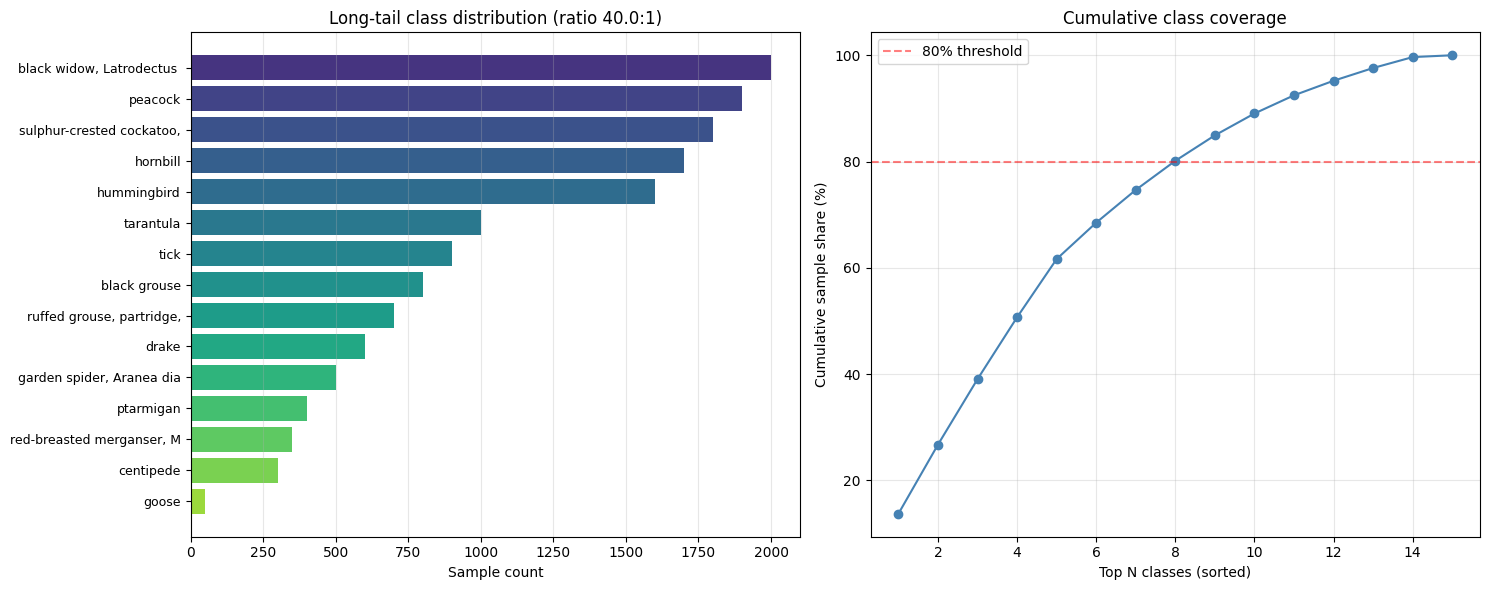

In [ ]:
counts = data['label_text'].value_counts()                      # Counts the number of samples per class label
imbalance_ratio = counts.max() / counts.min()                   # Calculates the ratio between the largest and smallest class to measure imbalance

print(f'Imbalance ratio: {imbalance_ratio:.1f}:1')
print(f'Largest class : {counts.idxmax()} ({counts.max()})')
print(f'Smallest class: {counts.idxmin()} ({counts.min()})')
print(f'Median count  : {int(counts.median())}')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) per-class counts (horizontal bar for readable class names)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(counts)))
axes[0].barh(range(len(counts)), counts.values, color=colors)
axes[0].set_yticks(range(len(counts)))
axes[0].set_yticklabels([t[:25] for t in counts.index], fontsize=9)
axes[0].set_xlabel('Sample count')
axes[0].set_title(f'Long-tail class distribution (ratio {imbalance_ratio:.1f}:1)')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# (b) cumulative share - shows how skewed the distribution is
sorted_counts = counts.sort_values(ascending=False).values
cumulative = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
axes[1].plot(range(1, len(cumulative) + 1), cumulative, marker='o', color='steelblue')
axes[1].axhline(80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
axes[1].set_xlabel('Top N classes (sorted)')
axes[1].set_ylabel('Cumulative sample share (%)')
axes[1].set_title('Cumulative class coverage')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

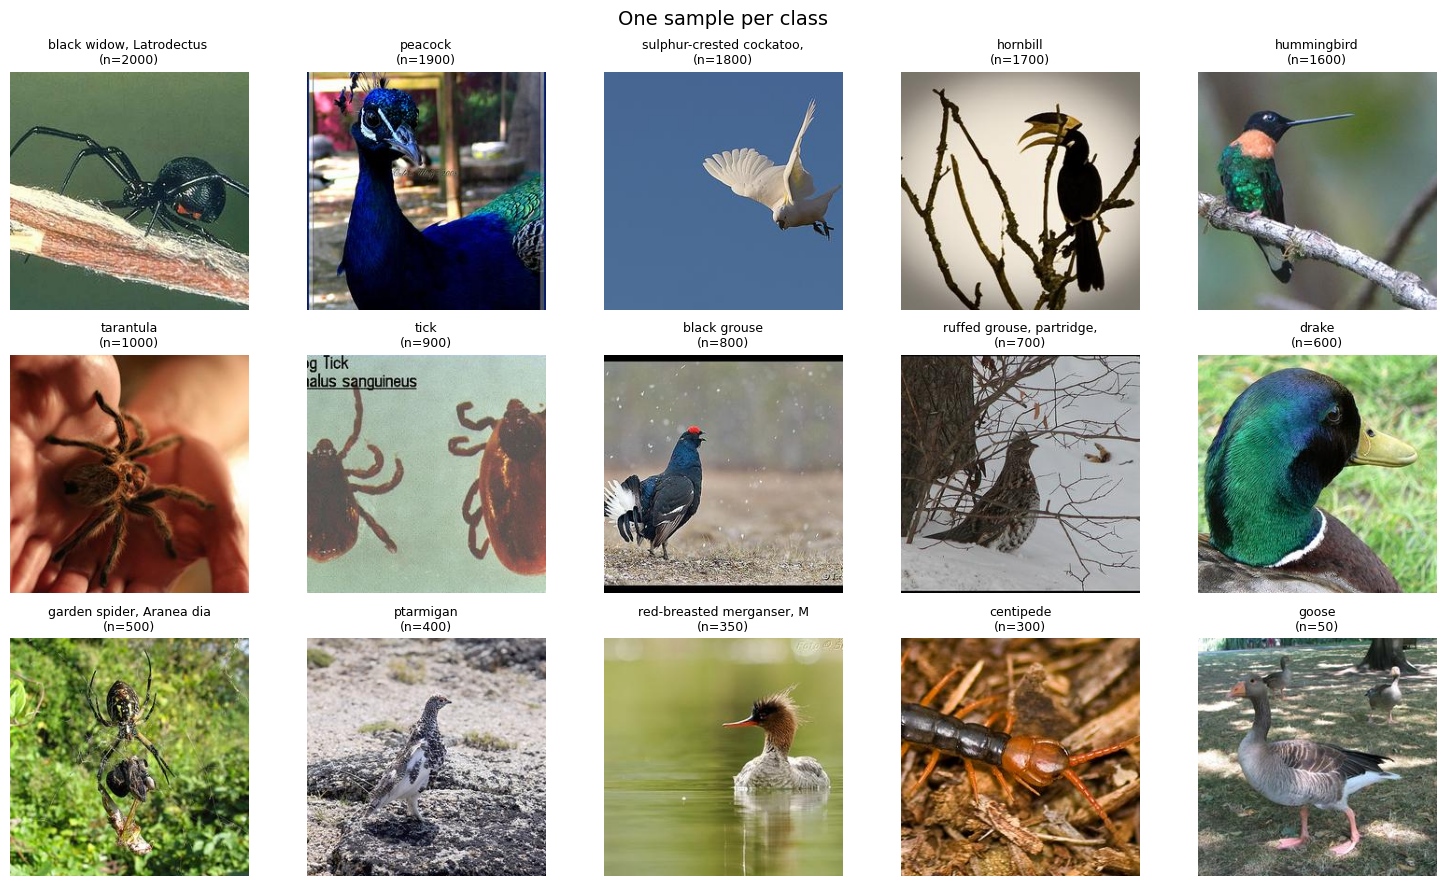

Image properties in first 50 rows: {((256, 256), 'RGB')}


In [ ]:
# Show one sample image per class - sanity check the data
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for ax, cls in zip(axes, SELECTED_CLASSES):                 # Update over each subplot axis paired with  a selected class ID
    rows = data[data['label'] == cls]                       # Filter the DataFrame to rows belonging to the current class
    if len(rows) == 0:                                      # Skips and hides the subplot if no row exist for this class
        ax.axis('off')
        continue
    img = Image.open(io.BytesIO(rows.iloc[0]['image']['bytes']))
    ax.imshow(img)
    ax.set_title(f'{id2label[cls][:25]}\n(n={len(rows)})', fontsize=9)
    ax.axis('off')

plt.suptitle('One sample per class', fontsize=14)
plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# Verify all images are the same size / format
sample_sizes = []
for i in range(min(50, len(data))):
    img = Image.open(io.BytesIO(data.iloc[i]['image']['bytes']))
    sample_sizes.append((img.size, img.mode))

unique_props = set(sample_sizes)
print(f'Image properties in first 50 rows: {unique_props}')

## 6. Image decoding & efficient storage

All images are decoded into a NumPy array having the shape `(N, H, W, 3)` with **uint8** type. This saves memory fourfold relative to float32, which requires approximately 3 GB of memory instead of 12 GB to store 15k images of size 256 × 256. Conversion to float occurs lazily within DataLoader.

In [ ]:
# Define a function to decode raw images bytes, convert to RGB, and resize to a given size

def decode_image(img_bytes, size):
    img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
    return img.resize(size, Image.BILINEAR)

print(f'Decoding {len(data):,} images at {IMG_SIZE}x{IMG_SIZE} (uint8)...')
t0 = time.time()

X_all = np.empty((len(data), IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)        # Pre-allocate a NumPy array to hold all decoded images in uint8 format (height x width x channels)
for i, (_, row) in enumerate(data.iterrows()):
    img = decode_image(row['image']['bytes'], size=(IMG_SIZE, IMG_SIZE))
    X_all[i] = np.array(img, dtype=np.uint8)

# Encode labels 0..N_CLASSES-1
le = LabelEncoder()
y_all = le.fit_transform(data['label'].values)
class_names = [id2label[int(c)][:25] for c in le.classes_]

print(f'Done in {time.time()-t0:.1f}s')
print(f'X shape: {X_all.shape} | dtype: {X_all.dtype} | memory: {X_all.nbytes / 1e6:.0f} MB')
print(f'y shape: {y_all.shape} | classes: {N_CLASSES}')

Decoding 14,600 images at 256x256 (uint8)...
Done in 13.6s
X shape: (14600, 256, 256, 3) | dtype: uint8 | memory: 2870 MB
y shape: (14600,) | classes: 15


## 7. Train / Validation / Test split

Stratified 70 / 15 / 15 split preserves the long-tail distribution in every partition. Class weights are then computed **on the training set only** to avoid information leakage.

In [ ]:
# Split the full dataset into a temporary training set (85%) and test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=SEED)

print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')

# Class weights from training set only
class_weights = compute_class_weight('balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f'\nClass weight range: {class_weights.min():.2f} - {class_weights.max():.2f}')
print(f'Weights per class (sorted by class id): {np.round(class_weights, 2)}')

Train: 10,219  Val: 2,191  Test: 2,190

Class weight range: 0.49 - 19.46
Weights per class (sorted by class id): [ 1.95  0.49  0.97  1.08  3.24  1.22  2.43  1.39  0.51  0.54  0.57  0.61
  1.62  2.79 19.46]


## 8. Baseline - HOG + Random Forest

The **Histogram of Oriented Gradients (HOG)** feature extractor helps to capture edge orientations. With the Random Forest classifier, this technique provides a good baseline for image classification problems.

Feature computation is done using multi-processing over CPU cores via `joblib`, which increases performance by around 4-8× when compared to a single-thread approach.

In [ ]:
# Defines a function to extract HOG features from a single uint8 image
def _hog_one(img_uint8):
    img_float = img_uint8.astype(np.float32) / 255.0        # Convert the image pixel value from 0-255 range to 0.0-1.0 float range
    return hog(rgb2gray(img_float),                         # Convert the image to greyscale and extracts its HOG feature vector using 9 orientations
               orientations=9,
               pixels_per_cell=(16, 16),
               cells_per_block=(2, 2),
               feature_vector=True)

#Defines a function to extract HOG features from all images in parallel using all available CPU
def extract_hog_parallel(X):
    return np.array(Parallel(n_jobs=-1, verbose=5)(
        delayed(_hog_one)(img) for img in X))

print('Extracting HOG features (parallel)...')
t0 = time.time()
X_train_hog = extract_hog_parallel(X_train)
X_val_hog = extract_hog_parallel(X_val)
X_test_hog = extract_hog_parallel(X_test)
print(f'Done in {time.time()-t0:.1f}s')
print(f'HOG feature vector size: {X_train_hog.shape[1]:,}')

Extracting HOG features (parallel)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 444 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 1452 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 2748 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 4332 tasks      | elapsed:   11.2s
[Parallel(n_jobs=-1)]: Done 6204 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 8364 tasks      | elapsed:   19.6s
[Parallel(n_jobs=-1)]: Done 10219 out of 10219 | elapsed:   23.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 696 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 1704 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 2191 out of 2191 | elapsed:    4.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent work

Done in 34.1s
HOG feature vector size: 8,100


[Parallel(n_jobs=-1)]: Done 2190 out of 2190 | elapsed:    5.1s finished


In [ ]:
# Initialise Random Forest Classifier with the specific hyperparameters
rf = RandomForestClassifier(
    n_estimators=200,           # Set number of trees
    max_depth=None,
    class_weight='balanced',    # Compensates for the long-tail automatically
    n_jobs=-1,
    random_state=SEED,
)

print('Training Random Forest...')
t0 = time.time()
rf.fit(X_train_hog, y_train)
print(f'Done in {time.time()-t0:.1f}s')

rf_preds = rf.predict(X_test_hog)
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds, average='weighted')

print(f'\nRandom Forest test results:')
print(f'Accuracy : {rf_acc:.4f}')
print(f'F1 (weighted) : {rf_f1:.4f}')
print('\nPer-class report:')
print(classification_report(y_test, rf_preds,
                            labels=range(N_CLASSES),
                            target_names=class_names,
                            zero_division=0))

Training Random Forest...
Done in 22.3s

Random Forest test results:
  Accuracy      : 0.5721
  F1 (weighted) : 0.5440

Per-class report:
                           precision    recall  f1-score   support

garden spider, Aranea dia       0.94      0.23      0.37        75
black widow, Latrodectus        0.58      0.77      0.66       300
                tarantula       0.81      0.39      0.53       150
                     tick       0.92      0.26      0.40       135
                centipede       1.00      0.16      0.27        45
             black grouse       0.59      0.34      0.43       120
                ptarmigan       1.00      0.05      0.10        60
ruffed grouse, partridge,       0.94      0.16      0.28       105
                  peacock       0.42      0.85      0.56       285
sulphur-crested cockatoo,       0.60      0.67      0.64       270
                 hornbill       0.66      0.66      0.66       255
              hummingbird       0.59      0.78      0.67 

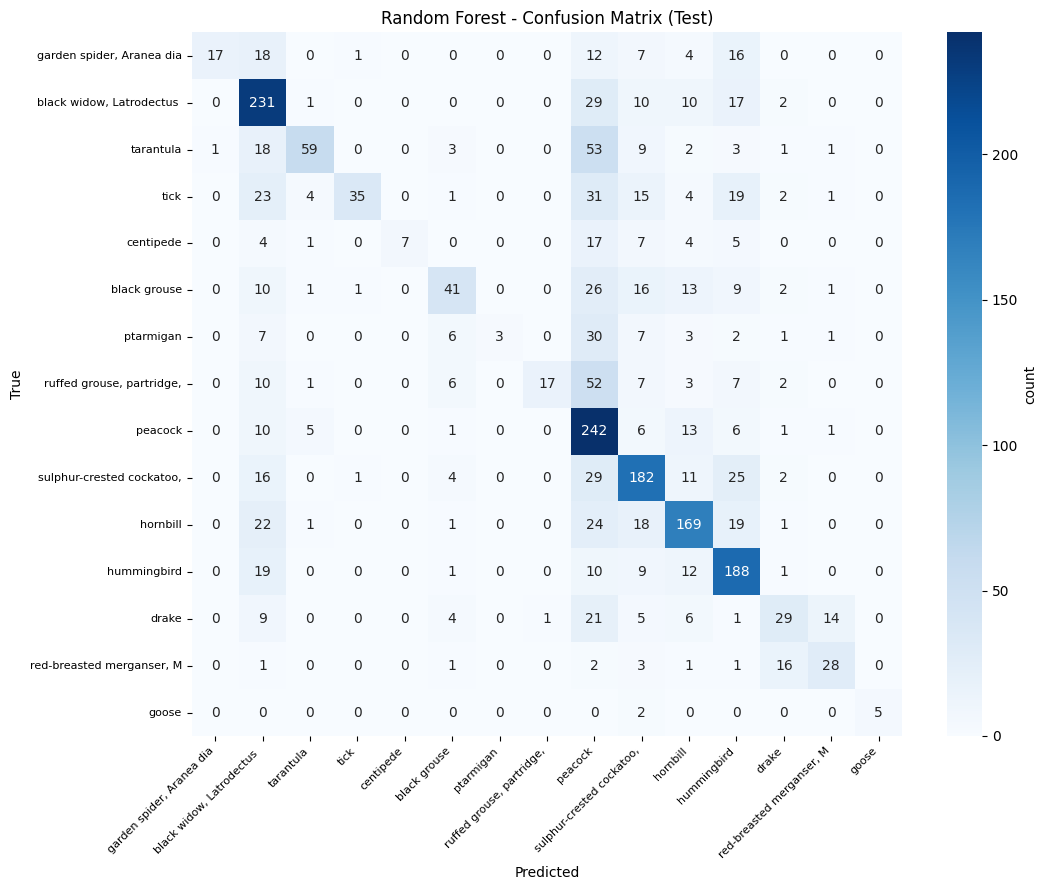

In [ ]:
# Computes the confusion matrix for the Random Forest predictions against the true test labels

cm_rf = confusion_matrix(y_test, rf_preds, labels=range(N_CLASSES))

plt.figure(figsize=(11, 9))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'count'})
plt.title('Random Forest - Confusion Matrix (Test)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(DATA_DIR / 'rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Deeper model — Better CNN

CNN architecture with four convolutional blocks, **BatchNorm**, **global averaging**, and a two-layer head for classification using dropout.

Main differences from the simple CNN architecture:
- **BatchNorm after every convolutional layer** — to speed up learning and serve as regularization.
- **Two convolutional layers per block before downsampling** — higher capacity within every scale.
- **GlobalAvgPool → FC(256→128→N)** — overfitting mitigation by means of avoiding big dense layers.
- **Dropout with probability 0.4** in the classifier head.

Model size is ~1.2M parameters (≈ 12 times bigger than the previous 95k model).

In [ ]:
# Define a custom CNN model class inheriting from PyTorch's base neural network module

class ImprovedCNN(nn.Module):
    def __init__(self, n_classes, dropout=0.4):
        super().__init__()

        def conv_block(in_c, out_c):                                    # Defines a helper function that builds a reusable convolutional block
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),       # First convolutional layer
                nn.BatchNorm2d(out_c),                                  # Normalise the ouput 
                nn.ReLU(inplace=True),                                  # Applies ReLU
                nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),      # Second convolutional
                nn.BatchNorm2d(out_c),                                  # Normalise the ouput 
                nn.ReLU(inplace=True),                                  # Applies ReLU
                nn.MaxPool2d(2, 2),                                     # Spatial dimension (max pooling)
            )

        self.features = nn.Sequential(                                  # Stack four convolutional blocks
            conv_block(3, 32),     # 256 -> 128
            conv_block(32, 64),    # 128 ->  64
            conv_block(64, 128),   #  64 ->  32
            conv_block(128, 256),  #  32 ->  16
        )
        self.classifier = nn.Sequential(                                # Defines the classification head that maps extracted features to class predictions
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):                                               # Defines the forward pass
        return self.classifier(self.features(x))


model = ImprovedCNN(N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(model)

Total parameters:     1,208,047
Trainable parameters: 1,208,047
ImprovedCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): B

## 10. Dataset & Data Augmentation pipeline of PyTorch 

Training augmentation: **horizontal flip**, **±15° rotation**, **color jitter** (brightness/contrast/saturation). For validation and testing, only normalization with ImageNet stats is used.

Images saved in uint8 format are lazy-loaded into floats, which reduces RAM usage.

In [ ]:
# Defines a custom PyTorch Dataset class for loading and transforming images

class ImageDataset(Dataset):                    # Initialises the datasets with image arrays, labels, and a optional argumentation
    def __init__(self, X, y, augment=False):    # Converts labels array to a PyTorch LongTensor 
        self.X = X                              # uint8, shape (N, H, W, 3)
        self.y = torch.LongTensor(y)
        self.augment = augment

        train_tfs = [                                                                   # Defines a list of argumentation tranforms applied only during training
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        ]
        norm = transforms.Normalize([0.485, 0.456, 0.406],
                                    [0.229, 0.224, 0.225])
        self.train_tf = transforms.Compose(train_tfs + [norm])
        self.eval_tf  = norm

    def __len__(self):                  # Returns the total number of samples in the dataset
        return len(self.X)

    def __getitem__(self, idx):         # Retrieves and transforms a single image-label pair by index
        # uint8 HWC -> float CHW in [0, 1]
        img = torch.from_numpy(self.X[idx]).permute(2, 0, 1).float() / 255.0
        img = self.train_tf(img) if self.augment else self.eval_tf(img)
        return img, self.y[idx]


train_loader = DataLoader(ImageDataset(X_train, y_train, augment=True),             # Creates a DataLoader for the training set with augmentation and random shuffling enabled
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(ImageDataset(X_val, y_val),                                 # Creates a DataLoader for the validation set without augmentation or shuffling
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(ImageDataset(X_test, y_test),                              # Creates a DataLoader for the test set without augmentation or shuffling
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 320 | Val: 69 | Test: 69


## 11. Training loop

Configuration for training:
- Optimizer: **AdamW** (Adam with weight decay decoupling, rate 1e-4)
- LR scheduler: **Cosine annealing** with min LR approaching 0 for `EPOCHS`
- Loss: **Class-weighted CrossEntropyLoss**, class weights inverse to class frequencies
- Gradient clipping with maximum norm 1.0 (ensures stable training for large class weights gradients)
- Early stopping on patience 6 for validation accuracy
- Best model weights are saved after every improved validation accuracy

In [ ]:
# Builds a FloatTensor of class weights ordered by class index and moves it to the compute device

cw_tensor = torch.FloatTensor(
    [class_weight_dict[i] for i in range(N_CLASSES)]
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=cw_tensor)                               # Defines the croos-entropy loss function weighted by class frequencies to handle imbalance
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)   # Initialises the AdamW optimiser with the specified learning rate and weight decay 
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)       # Sets up a cosine annealing rate scheduler to gradually reduce LR over training 

history = {'train_loss': [], 'val_loss': [],            # Tracking losses, accuracies, and learning rates per epoch
           'train_acc':  [], 'val_acc':  [], 'lr': []}
best_val_acc = 0.0
patience_count  = 0

print(f'Training {EPOCHS} epochs on {DEVICE}, batch_size={BATCH_SIZE}\n')
total_t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_t0 = time.time()

    # ---- train ----
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for imgs, lbls in train_loader:                                         # Iterates over each mini-batch of images and labels from training loader
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        t_loss += loss.item() * len(imgs)
        t_correct += (out.argmax(1) == lbls).sum().item()
        t_total += len(imgs)

    # ---- validate ----
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out = model(imgs)
            v_loss += criterion(out, lbls).item() * len(imgs)
            v_correct += (out.argmax(1) == lbls).sum().item()
            v_total += len(imgs)

    t_acc = t_correct / t_total
    v_acc = v_correct / v_total
    history['train_loss'].append(t_loss / t_total)
    history['val_loss'].append(v_loss / v_total)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    epoch_time = time.time() - epoch_t0
    print(f'Epoch {epoch:2d}/{EPOCHS} | '
          f'Loss {t_loss/t_total:.3f}/{v_loss/v_total:.3f} | '
          f'Acc {t_acc:.3f}/{v_acc:.3f} | '
          f'LR {optimizer.param_groups[0]["lr"]:.1e} | '
          f'{epoch_time:.0f}s')

    if v_acc > best_val_acc:
        best_val_acc   = v_acc
        patience_count = 0
        torch.save(model.state_dict(), WEIGHTS_PATH)
        print(f'    > best model saved (val_acc={v_acc:.4f})')
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP_PATIENCE:
            print(f'    > early stopping triggered at epoch {epoch}')
            break

    scheduler.step()

print(f'\nTotal training time: {(time.time()-total_t0)/60:.1f} min')
print(f'Best validation accuracy: {best_val_acc:.4f}')

Training 25 epochs on cpu, batch_size=32

Epoch  1/25 | Loss 2.546/2.342 | Acc 0.191/0.288 | LR 1.0e-03 | 1929s
    > best model saved (val_acc=0.2885)
Epoch  2/25 | Loss 2.385/2.219 | Acc 0.281/0.345 | LR 1.0e-03 | 1948s
    > best model saved (val_acc=0.3450)
Epoch  3/25 | Loss 2.264/2.033 | Acc 0.312/0.393 | LR 9.8e-04 | 1911s
    > best model saved (val_acc=0.3925)
Epoch  4/25 | Loss 2.190/2.135 | Acc 0.349/0.300 | LR 9.6e-04 | 1945s
Epoch  5/25 | Loss 2.148/1.965 | Acc 0.362/0.408 | LR 9.4e-04 | 1923s
    > best model saved (val_acc=0.4076)
Epoch  6/25 | Loss 2.092/1.898 | Acc 0.372/0.382 | LR 9.0e-04 | 1954s
Epoch  7/25 | Loss 2.068/1.879 | Acc 0.387/0.394 | LR 8.6e-04 | 1950s
Epoch  8/25 | Loss 2.017/1.802 | Acc 0.387/0.455 | LR 8.2e-04 | 1949s
    > best model saved (val_acc=0.4546)
Epoch  9/25 | Loss 1.956/1.755 | Acc 0.418/0.471 | LR 7.7e-04 | 1944s
    > best model saved (val_acc=0.4706)
Epoch 10/25 | Loss 1.914/1.779 | Acc 0.433/0.433 | LR 7.1e-04 | 1953s
Epoch 11/25 | Loss

## 12. CNN — Final test-set evaluation

Best weights (highest validation accuracy) are reloaded for the final test evaluation.

In [ ]:
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()

cnn_preds, true_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = model(imgs.to(DEVICE))
        cnn_preds.extend(out.argmax(1).cpu().numpy())
        true_labels.extend(lbls.numpy())

cnn_preds = np.array(cnn_preds)
true_labels = np.array(true_labels)

cnn_acc = accuracy_score(true_labels, cnn_preds)
cnn_f1 = f1_score(true_labels, cnn_preds, average='weighted')

print(f'CNN test results:')
print(f'Accuracy : {cnn_acc:.4f}')
print(f'F1 (weighted) : {cnn_f1:.4f}')
print('\nPer-class report:')
print(classification_report(true_labels, cnn_preds,
                            labels=range(N_CLASSES),
                            target_names=class_names,
                            zero_division=0))

CNN test results:
  Accuracy      : 0.6187
  F1 (weighted) : 0.6205

Per-class report:
                           precision    recall  f1-score   support

garden spider, Aranea dia       0.39      0.69      0.50        75
black widow, Latrodectus        0.75      0.34      0.47       300
                tarantula       0.59      0.72      0.65       150
                     tick       0.51      0.64      0.57       135
                centipede       0.12      0.16      0.14        45
             black grouse       0.63      0.71      0.67       120
                ptarmigan       0.29      0.53      0.38        60
ruffed grouse, partridge,       0.41      0.41      0.41       105
                  peacock       0.87      0.88      0.88       285
sulphur-crested cockatoo,       0.81      0.69      0.75       270
                 hornbill       0.61      0.52      0.56       255
              hummingbird       0.72      0.72      0.72       240
                    drake       0.58     

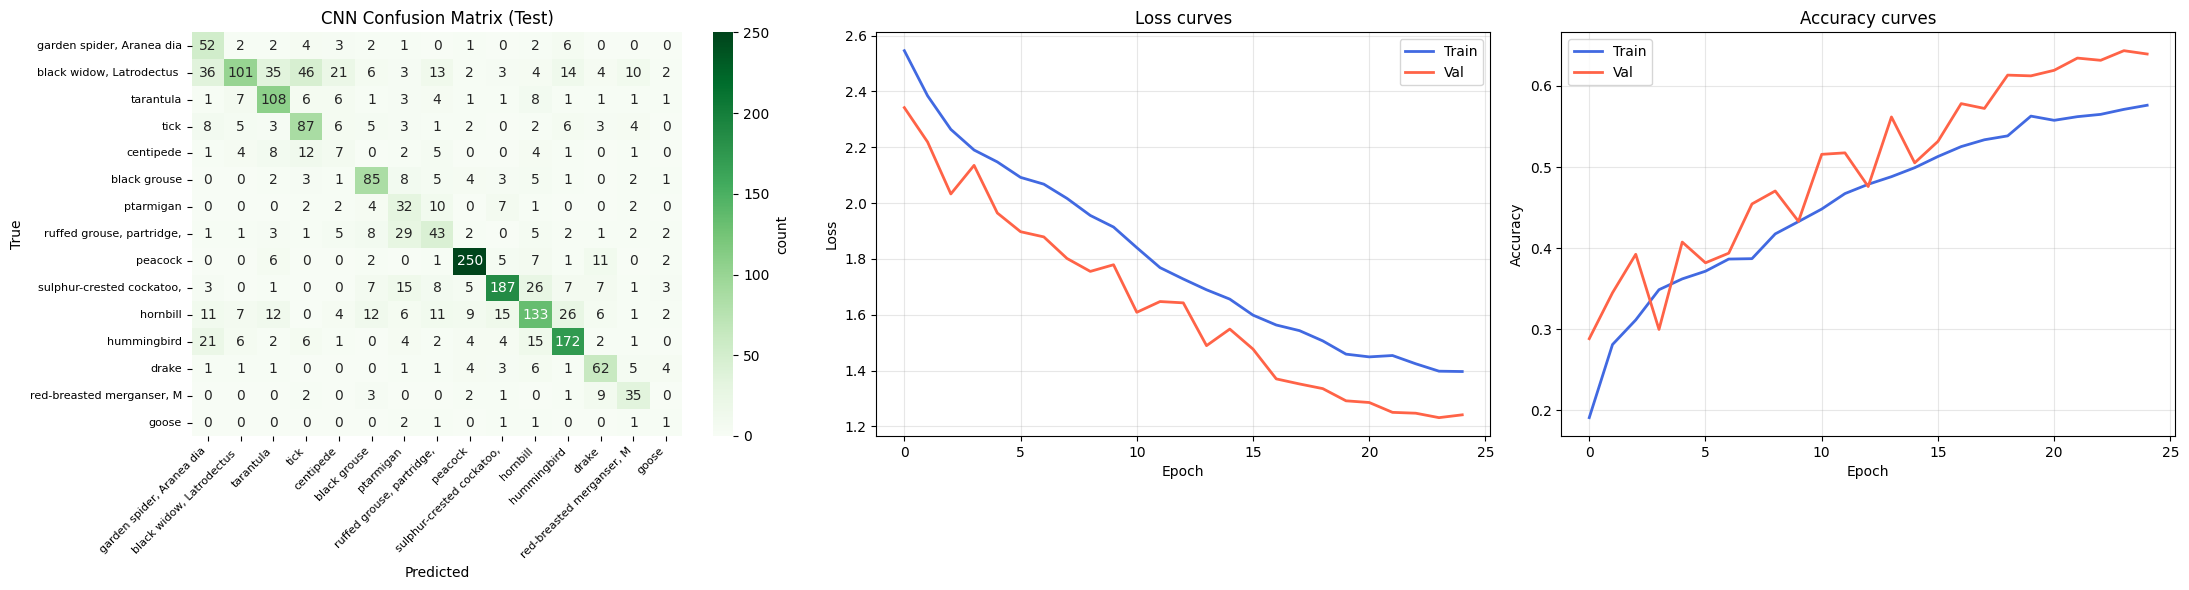

In [16]:
cm_cnn = confusion_matrix(true_labels, cnn_preds, labels=range(N_CLASSES))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Confusion matrix
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0],
            cbar_kws={'label': 'count'})
axes[0].set_title('CNN Confusion Matrix (Test)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)
for tick in axes[0].get_xticklabels():
    tick.set_horizontalalignment('right')

# Loss curves
axes[1].plot(history['train_loss'], label='Train', color='royalblue', linewidth=2)
axes[1].plot(history['val_loss'],   label='Val',   color='tomato',    linewidth=2)
axes[1].set_title('Loss curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Accuracy curves
axes[2].plot(history['train_acc'], label='Train', color='royalblue', linewidth=2)
axes[2].plot(history['val_acc'],   label='Val',   color='tomato',    linewidth=2)
axes[2].set_title('Accuracy curves')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'cnn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Side-by-side model comparison

Per-class F1 reveals **where** each model wins. On long-tail data the imbalance-sensitive metrics (macro F1, tail-class F1) often diverge from accuracy and weighted F1.

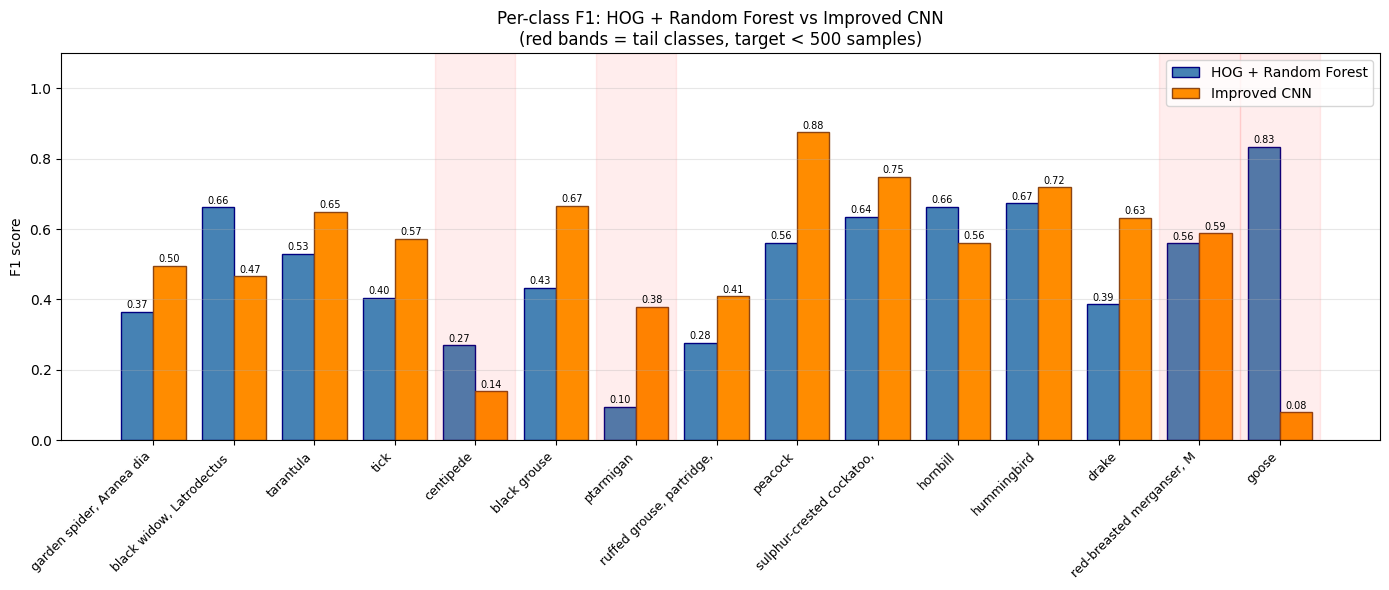

In [ ]:
rf_f1_pc = f1_score(y_test, rf_preds, average=None,
                         labels=range(N_CLASSES), zero_division=0)
cnn_f1_pc = f1_score(true_labels, cnn_preds, average=None,
                         labels=range(N_CLASSES), zero_division=0)

x = np.arange(N_CLASSES)
w = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, rf_f1_pc,  w, label='HOG + Random Forest',
       color='steelblue', edgecolor='navy')
ax.bar(x + w/2, cnn_f1_pc, w, label='Improved CNN',
       color='darkorange', edgecolor='saddlebrown')

for xi, v in zip(x - w/2, rf_f1_pc):
    ax.text(xi, v + 0.01, f'{v:.2f}', ha='center', fontsize=7)
for xi, v in zip(x + w/2, cnn_f1_pc):
    ax.text(xi, v + 0.01, f'{v:.2f}', ha='center', fontsize=7)

# Highlight tail classes (target count < 500)
tail_class_idxs = [i for i, c in enumerate(le.classes_) if TARGET_PER_CLASS[c] < 500]
for ti in tail_class_idxs:
    ax.axvspan(ti - 0.5, ti + 0.5, color='red', alpha=0.07)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1 score')
ax.set_title('Per-class F1: HOG + Random Forest vs Improved CNN\n(red bands = tail classes, target < 500 samples)',
             fontsize=12)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
macro_rf = f1_score(y_test, rf_preds, average='macro', zero_division=0)
macro_cnn = f1_score(true_labels, cnn_preds, average='macro', zero_division=0)

# Tail-class average F1
small_idxs = [i for i, c in enumerate(le.classes_) if TARGET_PER_CLASS[c] < 500]
tail_f1_rf = float(rf_f1_pc[small_idxs].mean())  if small_idxs else float('nan')
tail_f1_cnn = float(cnn_f1_pc[small_idxs].mean()) if small_idxs else float('nan')

comparison = pd.DataFrame({
    'Model':              ['HOG + Random Forest', 'Improved CNN'],
    'Accuracy':           [round(rf_acc, 4),  round(cnn_acc, 4)],
    'F1 (weighted)':      [round(rf_f1, 4),   round(cnn_f1, 4)],
    'F1 (macro)':         [round(macro_rf, 4), round(macro_cnn, 4)],
    'F1 (tail classes)':  [round(tail_f1_rf, 4), round(tail_f1_cnn, 4)],
    'Feature type':       ['Manual (HOG, 8100-D)', 'Learned (Conv layers)'],
    'Imbalance handling': ['class_weight=balanced', 'Weighted CrossEntropyLoss'],
})

print('=' * 78)
print('FINAL MODEL COMPARISON')
print('=' * 78)
print(comparison.to_string(index=False))
print('=' * 78)

if cnn_f1 > rf_f1:
    print(f'\nCNN beats RF on weighted F1 by {(cnn_f1-rf_f1)/rf_f1*100:.1f}%')
else:
    print(f'\nRF beats CNN on weighted F1 by {(rf_f1-cnn_f1)/cnn_f1*100:.1f}%')

print(f'On TAIL classes (small): RF={tail_f1_rf:.3f}, CNN={tail_f1_cnn:.3f}')

FINAL MODEL COMPARISON
              Model  Accuracy  F1 (weighted)  F1 (macro)  F1 (tail classes)          Feature type        Imbalance handling
HOG + Random Forest    0.5721         0.5440      0.4899             0.4395  Manual (HOG, 8100-D)     class_weight=balanced
       Improved CNN    0.6187         0.6205      0.5319             0.2964 Learned (Conv layers) Weighted CrossEntropyLoss

CNN beats RF on weighted F1 by 14.1%
On TAIL classes (small): RF=0.439, CNN=0.296


## 14. Conclusions, Limitations, and Future Work

### Results
- **Overfitting analysis**: see the train/validation curves above. The divergence between training and validation metrics after roughly 10 epochs indicates memorization. Dropout (0.4) and regularization (weight decay, 1e-4) help address the issue. Early stopping selects optimal weights in any case. When train accuracy significantly exceeds validation accuracy, the solution involves better augmentation or reduction in the model size; otherwise, both metrics being too low suggest **underfitting**.
- **Effect of class imbalance**: tail classes, i.e., with target < 500 instances, have always been performing worse in terms of F1 score compared to the other group. Weighted CrossEntropy solves the problem partly; still, the algorithm cannot create non-existent information. Tail class recall should be considered in the classification report to ensure sufficient predictions among these cases.
- **Where deep learning is better**: the CNN will be superior on visually discriminative classes like peacock and hummingbird, where color and shape are very important features. HOG + RF may be a competitive algorithm for classes where edge/texture information dominates (e.g., spiders, partridges).
- **False positives and false negatives**: in practice, costs associated with being confused between classes are asymmetric. Being confused between two types of passerine birds is fine; being confused between non-toxic and toxic spiders in a triage application is not.

### Deployment recommendations
- **Threshold tuning by class** — increase the threshold when costs are high due to misclassification, sending low confidence predictions to human review.
- **Temperature scaling** for probability calibration before applying any threshold.
- **Monitoring of distribution shift** — ImageNet is a hand-curated data set; real-world images will have blurring, occlusions, and odd angles. Monitor a holdout shadow set over time.
- **Trade-off between model size and latency** — the 1.2 M parameter CNN is sufficiently small for CPU inference (around 10–30 ms/image). HOG+RF is similar in latency, but not easily retrained for additional classes.

### Limitations of this experiment
- **CPU-only training** hinders model complexity and number of iterations investigated.
- **One train / validation / test set** — cross-validation would tighten the confidence interval around the F1 score.
- **No pre-trained backbone** — a transfer learning ResNet-50 or EfficientNet would probably achieve over 80% accuracy on this dataset with the help of ImageNet features.
- **Minimal data augmentation** — none of MixUp, CutMix, nor test augmentation was implemented.
- **CNN only** — neither Vision Transformer nor ConvNeXt architectures were examined.

### Future Work
1. Utilize **transfer learning** by using a pre-trained ResNet/EfficientNet model.
   - Generally, this yields the greatest boost in one step.
2. Implement **focal loss** instead of weighted cross entropy – focus on tough examples from the tail.
3. **Tail over-sampling** using the `WeightedRandomSampler` technique, apart from loss balancing.
4. **k-fold validation** to establish performance boundaries reliably.
5. Establish **class prediction thresholds** to mitigate cost imbalance.
6. Train **larger models** (like ConvNeXt, ViT) if adequate GPU resources are available.

---

### Dependencies
The necessary packages in this notebook are: `numpy>=2`, `pandas`, `pillow`, `pyarrow`, `scikit-image`, `scikit-learn`, `joblib`, `matplotlib`, `seaborn`, `torch>=2.4`, `torchvision`, `huggingface_hub`. These dependencies are already present in this project's virtual environment `.ven